# Algorithms (SS13)
## Developer: Ayansewa Adedeji  
### Artificial Intelligence Applications (LIS 5377)

1. Requirements
    - Algorithms using Conda environment (ss13)
    - Make prediction using Credit Card data
    - Provide screenshots of completed python skill sets

In [1]:
# import necessary packages
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # for charts/plots
import seaborn as sns # for charts/plots
from sklearn.model_selection import train_test_split # for training/testing model

# for Random Forest classifier and accuracy score evaluator
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Resources:
# https://builtin.com/data-science/train-test-split
# https://builtin.com/data-science/random-forest-algorithm
# https://www.datacamp.com/tutorial/random-forests-classifier-python
# https://www.kaggle.com/code/prashant111/random-forest-classifier-tutorial

In [2]:
print(sys.version) # print python version
print(os.environ['CONDA_DEFAULT_ENV']) # print conda environment

3.9.21 (main, Dec 11 2024, 16:35:24) [MSC v.1929 64 bit (AMD64)]
testenv


In [3]:
# read csv file into DataFrame
df = pd.read_csv("credit_card.csv")

In [4]:
# DataFrame dimensions (rows/cols)
df.shape

(1319, 12)

In [5]:
type(df)

pandas.core.frame.DataFrame

In [6]:
# display column names
df.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [7]:
# first 5 records
df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [8]:
# binary recoding: change categorical variables 'yes' and 'no' into numeral format (though, still object!)
# Note: values replaced in original DataFrame--NOT .csv file!

with pd.option_context('future.no_silent_downcasting', True):
    df['card'] = df['card'].replace(['yes', 'no'], [1, 0])
    df['owner'] = df['owner'].replace(['yes', 'no'], [1, 0])
    df['selfemp'] = df['selfemp'].replace(['yes', 'no'], [1, 0])

df.head(5)

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


In [9]:
# isna() detects missing values (returns True or False)
# when combined with sum(), calculates total number of missing values (True=1, and False=0)

# validate data (no "Not Available" values)
df.isna().sum()

# Note: df.isnull().sum() functionally identical to df.isna().sum()
# Strictly matter of preference. Though, isna() aligns with other Pandas functions like dropna() and fillna()

card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64

In [10]:
df.describe()

# Note: describe() did NOT include objects (i.e., 'card' 'owner' 'selfemp')

,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [11]:
# list variable types BEFORE conversion
df.dtypes

# Note: errors='coerce' turns unconvertible values into NaN
# df['card'] = pd.to_numeric(df['card'], errors='coerce')
# df['owner'] = pd.to_numeric(df['owner'], errors='coerce')
# df['selfemp'] = pd.to_numeric(df['selfemp'], errors='coerce')

# Note: only use astype(numeric type) if confident ALL values in column can be converted to numeric type!
# e.g., .astype(int)

card            object
reports          int64
age            float64
income         float64
share          float64
expenditure    float64
owner           object
selfemp         object
dependents       int64
months           int64
majorcards       int64
active           int64
dtype: object

In [12]:
# list variable types AFTER conversion
df.dtypes

card            object
reports          int64
age            float64
income         float64
share          float64
expenditure    float64
owner           object
selfemp         object
dependents       int64
months           int64
majorcards       int64
active           int64
dtype: object

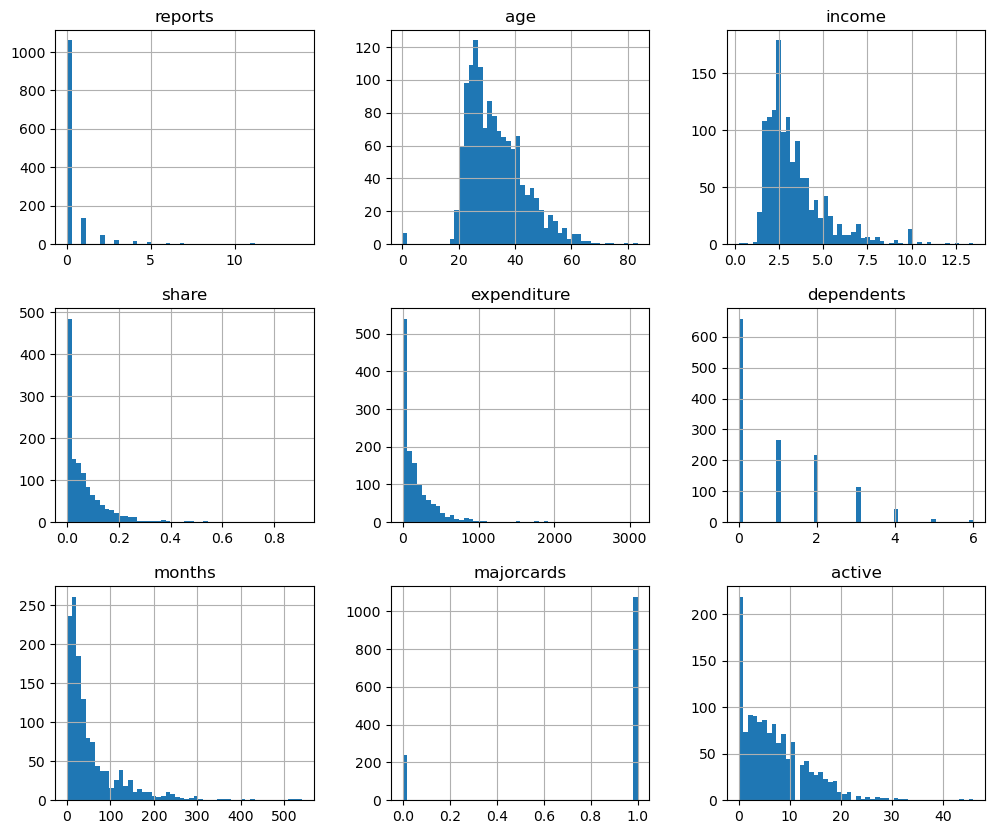

In [13]:
df.hist(bins=50, figsize=(12,10))
plt.show()

# Note: y-axis: feature values; x-axis: number of feature value occurrences
# Note: features distributed on different scales (permits same sized graphs); though, x and y-axis values vary

In [14]:
# display attribute correlations
df.corr(numeric_only=True)

,reports,age,income,share,expenditure,dependents,months,majorcards,active
reports,1.000000,0.044089,0.011023,-0.159011,-0.136538,0.019731,0.048968,-0.007304,0.207755
age,0.044089,1.000000,0.324653,-0.115697,0.014948,0.212146,0.436426,0.009777,0.181070
income,0.011023,0.324653,1.000000,-0.054429,0.281104,0.317601,0.130346,0.107138,0.180540
share,-0.159011,-0.115697,-0.054429,1.000000,0.838779,-0.082618,-0.055348,0.051470,-0.023474
expenditure,-0.136538,0.014948,0.281104,0.838779,1.000000,0.052664,-0.029007,0.077514,0.054724
dependents,0.019731,0.212146,0.317601,-0.082618,0.052664,1.000000,0.046512,0.010285,0.107133
months,0.048968,0.436426,0.130346,-0.055348,-0.029007,0.046512,1.000000,-0.041447,0.100028
majorcards,-0.007304,0.009777,0.107138,0.051470,0.077514,0.010285,-0.041447,1.000000,0.119603
active,0.207755,0.181070,0.180540,-0.023474,0.054724,0.107133,0.100028,0.119603,1.000000


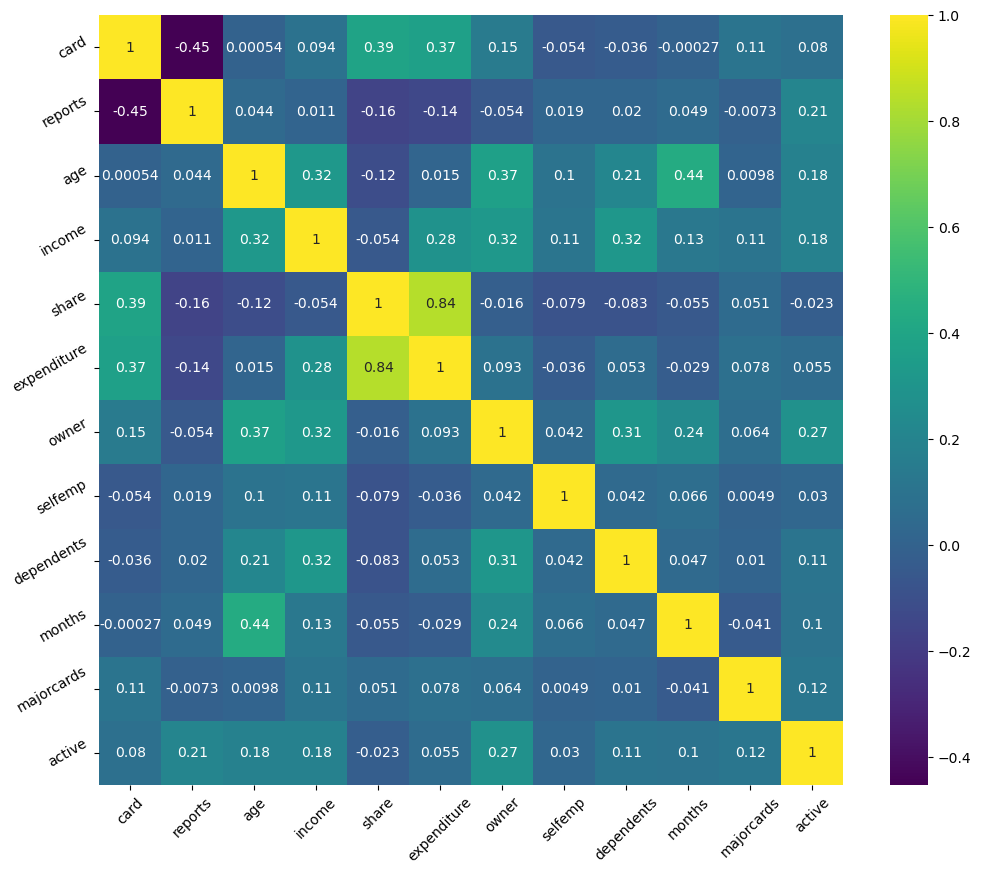

In [15]:
# Visually display correlations using Seaborn's heatmap() function.
# (https://seaborn.pydata.org/generated/seaborn.heatmap.html)

plt.figure(figsize=(12, 10))  # set figure size (default: 6.4" W x 4.8" H)
ax = sns.heatmap(df.corr(), cmap='viridis', annot = True)

# rotate x-axis labels 45 degrees
ax.tick_params(axis='x', labelrotation=45)

# rotate y-axis labels -30 degrees
ax.tick_params(axis='y', labelrotation=30)

plt.show()

# Note: "annot" property set to "True" so that cell-values are displayed in each cell.

In [16]:
# Note: target: "card" (i.e., credit card application accepted)
# "card" (0,1): nominal categorical variable (categorical: grouped into categories; nominal: no order or ranking)
# target variable (credit card application accepted)
y = df['card']

In [17]:
# extract features (card predictors)
X = df.drop('card', axis=1)

In [18]:
type(y) # display target type

pandas.core.series.Series

In [19]:
type(X) # display features type

pandas.core.frame.DataFrame

In [20]:
# display target values
y

0       1
1       1
2       1
3       1
4       1
       ..
1314    1
1315    0
1316    1
1317    1
1318    1
Name: card, Length: 1319, dtype: object

In [21]:
# display features (i.e., predictors) values
X

,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5
...,...,...,...,...,...,...,...,...,...,...,...
1314,0,33.58333,4.5660,0.002146,7.333333,1,0,0,94,1,19
1315,5,23.91667,3.1920,0.000376,0.000000,0,0,3,12,1,5
1316,0,40.58333,4.6000,0.026513,101.298300,1,0,2,1,1,2
1317,0,32.83333,3.7000,0.008999,26.996670,0,1,0,60,1,7


In [22]:
# value_counts(): returns Series containing frequency of each distinct row in DataFrame
# Note: index represents unique values, and values represent corresponding counts
# results sorted in desc order of frequency (default), and NaN (missing) values excluded

# display frequency distribution of values in variables, and variable types
for col in X:
    print(df[col].value_counts())

reports
0     1060
1      137
2       50
3       24
4       17
5       11
7        6
6        5
11       4
9        2
12       1
14       1
10       1
Name: count, dtype: int64
age
28.16667    13
25.16667    11
23.83333    11
26.08333    10
24.25000    10
            ..
49.00000     1
43.16667     1
61.58333     1
35.41667     1
58.08333     1
Name: count, Length: 418, dtype: int64
income
3.000     61
2.500     46
2.000     44
3.500     41
4.000     32
          ..
2.136      1
0.490      1
2.408      1
2.616      1
11.000     1
Name: count, Length: 431, dtype: int64
share
0.000480    12
0.000667    11
0.000600    11
0.000400    11
0.000462    10
            ..
0.048842     1
0.000432     1
0.026596     1
0.014780     1
0.133742     1
Name: count, Length: 1162, dtype: int64
expenditure
0.000000      317
4.583333        9
8.333333        8
7.083333        5
3.750000        2
             ... 
424.629200      1
7.333333        1
101.298300      1
26.996670       1
137.869200      1
Name:

In [23]:
# split data into training and testing (validation) sets
# Note: random_state is pseudo-random number generator to reproduce same train test split each time code runs
# Note: specify integer value doesn't matter; what matters is that same integer value is used to achieve reproducible results
# Note: only test_size or train_size need to be included, both NOT required. If neither, default 75 training/25 testing

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

# Trivia: if random_state value doesn't matter, why always 42?

# Answer(s):
# https://grsotagon.medium.com/what-is-random-state-42-d9a2870e76b
# https://en.wikipedia.org/wiki/42_(number)

In [24]:
# display X_train, X_test, y_train, y_test shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1055, 11), (264, 11), (1055,), (264,))

In [25]:
print(df['card'].head(10))
print(df['card'].dtype)
print(df['card'].unique())

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: card, dtype: object
object
[1 0]


In [26]:
df['card'] = pd.to_numeric(df['card'], errors='coerce')
df['card'] = df['card'].astype(int)

In [27]:
print(df['card'].head(10))
print(df['card'].dtype)
print(df['card'].unique())

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: card, dtype: int64
int64
[1 0]


In [28]:
y = df['card']
X = df.drop('card', axis=1)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [30]:
# create (instantiate) Random Forest Classifier
# Note: for testing purposes, initially use 10 decision-trees to build model.
# Then, test with 100 decision-trees.
# Does accuracy increase or decrease with number of decision-trees in model?
model = RandomForestClassifier(n_estimators=10, random_state=42)  # set hyperparameters

# train model
model.fit(X_train, y_train)

# display feature scores (highest to lowest)
feature_scores = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

share          0.594484
expenditure    0.242217
reports        0.065997
age            0.023173
months         0.022172
income         0.019440
active         0.011970
owner          0.007180
majorcards     0.006652
dependents     0.005018
selfemp        0.001697
dtype: float64

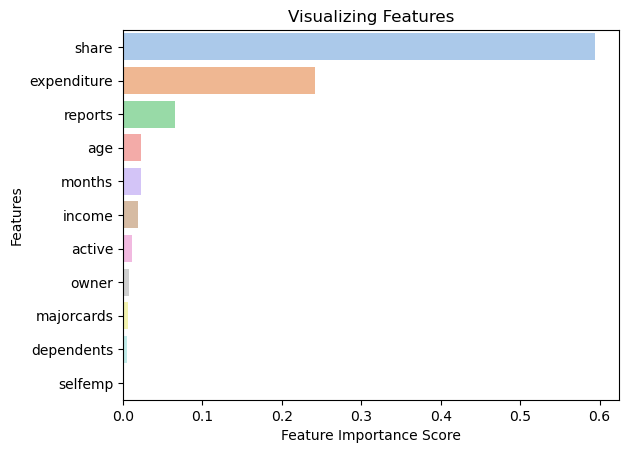

In [31]:
# visualize feature scores
# create seaborn bar plot (https://seaborn.pydata.org/generated/seaborn.barplot.html)
sns.barplot(x=feature_scores, y=feature_scores.index, hue=feature_scores.index, palette='pastel')

# add labels
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')

# add title
plt.title('Visualizing Features')

# display graph
plt.show()

In [32]:
# predictions on test set
y_pred = model.predict(X_test)

# evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Model accuracy score with 10 decision-trees: {0:0.2f}". format(accuracy))

# Or, using f-string format
# print(f"Accuracy: {accuracy:.2f}")

# Note: in classification analysis, dependent attribute is categorical.
# Common classification example: determine if email is spam (i.e., "yes"/"no" or 1/0)

# Some Random Forest Use Cases:
# Detects reliable debtors and potential fraudsters in finance
# Verifies medicine components and pollutant data in healthcare
# Gauges whether customers will like products in e-commerce

# BE SURE TO REVIEW THIS...
# https://www.kaggle.com/code/kuzmaphunteonry/intermediate-machine-learning?scriptVersionId=...

Model accuracy score with 10 decision-trees: 0.97
